In [16]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
# os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [17]:
# Cell 1 — Imports
import os
import sys
import joblib
import random
import yaml
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

sys.path.insert(0, "../src/models")
from preprocess import DatePreprocessor, SlidingWindowTransformer

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.16.2


In [18]:
# Cell 2 — Load params
params = yaml.safe_load(open("../params.yaml"))
train_params = params["train"]
preprocess_params = params["preprocess"]

test_size = train_params["test_size"]
window_size = train_params["window_size"]
target_col = train_params["target_col"]
feature_cols = train_params["feature_cols"]
random_state = train_params["random_state"]
data_path = "../" + preprocess_params["output_path"]

print(f"test_size: {test_size}")
print(f"window_size: {window_size}")
print(f"target_col: {target_col}")
print(f"feature_cols: {feature_cols}")

test_size: 90
window_size: 30
target_col: energy_demand
feature_cols: ['temp_max', 'temp_min', 'daylight_duration']


In [19]:
# Cell 3 — Reproducibility
os.environ["PYTHONHASHSEED"] = str(random_state)
random.seed(random_state)
np.random.seed(random_state)
tf.random.set_seed(random_state)

In [20]:
# Cell 4 — Load and filter data
df = pd.read_csv(data_path)
df = df[df["is_forecast"] == False].copy()
df = df[df[target_col].notna()].copy()
df = df[["Date", target_col] + feature_cols]

print(f"Shape after filtering: {df.shape}")
df.head()

Shape after filtering: (2306, 5)


,Date,energy_demand,temp_max,temp_min,daylight_duration
0,2020-01-01,1.278542,4.4,-4.6,31328.17
1,2020-01-02,1.371167,6.2,-6.2,31383.02
2,2020-01-03,1.510958,7.0,-6.2,31442.54
3,2020-01-04,1.504667,7.3,-5.6,31506.61
4,2020-01-05,1.473542,5.3,-4.9,31575.09


In [21]:
# Cell 5 — Fill missing dates
date_preprocessor = DatePreprocessor("Date")
df = date_preprocessor.fit_transform(df)
df = df.drop(columns=["Date"])

print(f"Shape after date fill: {df.shape}")
df.isnull().sum()

Shape after date fill: (2306, 4)


energy_demand        0
temp_max             0
temp_min             0
daylight_duration    0
dtype: int64

In [22]:
# Cell 6 — Train/test split
df_test = df.iloc[-test_size:]
df_train = df.iloc[:-test_size]

print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")

Train shape: (2216, 4)
Test shape: (90, 4)


In [23]:
# Cell 7 — Build pipeline
target_pipeline = Pipeline([
    ("fillna", SimpleImputer(strategy="mean")),
    ("normalize", MinMaxScaler())
])

feature_pipeline = Pipeline([
    ("fillna", SimpleImputer(strategy="mean")),
    ("normalize", MinMaxScaler())
])

preprocess = ColumnTransformer([
    ("target_transformer", target_pipeline, [target_col]),
    ("feature_transformer", feature_pipeline, feature_cols),
])

sliding_window_transformer = SlidingWindowTransformer(window_size)

pipeline = Pipeline([
    ("preprocess", preprocess),
    ("sliding_window_transformer", sliding_window_transformer),
])

In [24]:
# Cell 8 — Apply pipeline
X_train, y_train = pipeline.fit_transform(df_train)
X_test, y_test = pipeline.transform(df_test)

y_train = y_train[:, 0:1]
y_test = y_test[:, 0:1]

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

target_scaler = pipeline.named_steps["preprocess"].transformers_[0][1].named_steps["normalize"]

X_train shape: (2186, 30, 4), y_train shape: (2186, 1)
X_test shape: (60, 30, 4), y_test shape: (60, 1)


In [25]:
# Cell 9 — Build and train model (THIS IS THE SLOW CELL)
def build_model(input_shape):
    model = Sequential()
    model.add(LSTM(50, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer="adam", loss="mean_squared_error")
    return model

input_shape = (X_train.shape[1], X_train.shape[2])
model = build_model(input_shape)
model.summary()

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=60,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=500,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

/Users/bobanboshevski/FERI IPT/MAGISTERJI/2 Semester/Inženirstvo inteligentnih sistemov/VAJE/IIS projekt energija/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 50)         │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,251 (122.07 KB)

 Trainable params: 31,251 (122.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0481 - val_loss: 0.0177
Epoch 2/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0177 - val_loss: 0.0166
Epoch 3/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0178 - val_loss: 0.0165
Epoch 4/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0175 - val_loss: 0.0159
Epoch 5/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0170 - val_loss: 0.0157
Epoch 6/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0170 - val_loss: 0.0156
Epoch 7/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0164 - val_loss: 0.0156
Epoch 8/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0168 - val_loss: 0.0153
Epoch 9/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0158 - val_loss: 0.0151
Epoch 10/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0164 - val_loss: 0.0156
Epoch 11/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0156 - val_loss: 0.0154
Epoch 12/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

In [26]:
# Cell 10 — Evaluate on test set
y_pred = model.predict(X_test)

y_test_inv = target_scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = target_scaler.inverse_transform(y_pred)

mse = mean_squared_error(y_test_inv, y_pred_inv)
mae = mean_absolute_error(y_test_inv, y_pred_inv)
print(f"Test MAE:  {mae:.4f}")
print(f"Test MSE:  {mse:.4f}")
print(f"Test RMSE: {np.sqrt(mse):.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Test MAE:  0.0496
Test MSE:  0.0060
Test RMSE: 0.0775


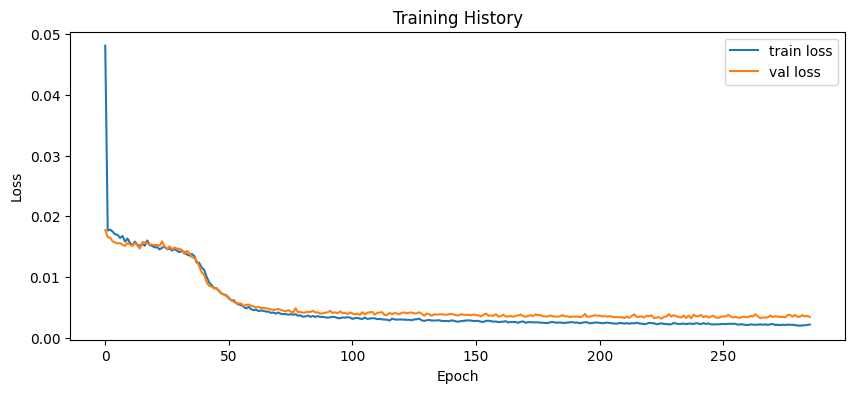

In [27]:
# Cell 11 — Plot training history
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training History")
plt.legend()
plt.show()

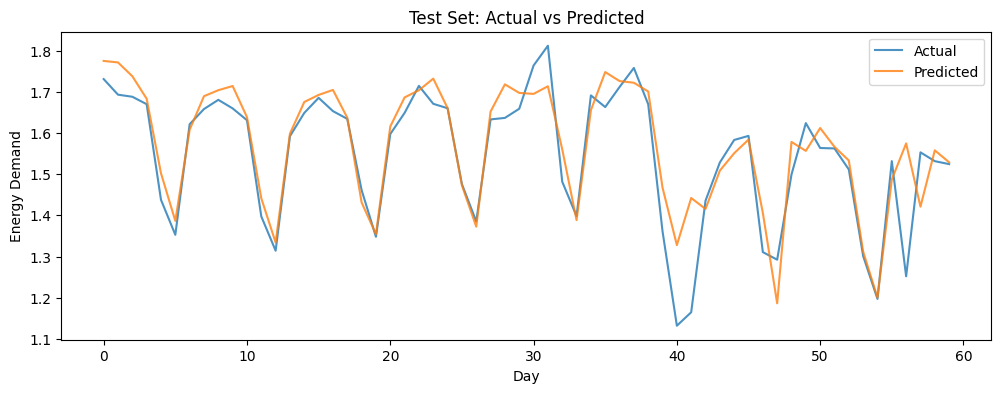

In [28]:
# Cell 12 — Plot predictions vs actual
plt.figure(figsize=(12, 4))
plt.plot(y_test_inv, label="Actual", alpha=0.8)
plt.plot(y_pred_inv, label="Predicted", alpha=0.8)
plt.xlabel("Day")
plt.ylabel("Energy Demand")
plt.title("Test Set: Actual vs Predicted")
plt.legend()
plt.show()

In [29]:
# Cell 13 — Train on full dataset
X_full, y_full = pipeline.fit_transform(df)
y_full = y_full[:, 0:1]

target_scaler_full = pipeline.named_steps["preprocess"].transformers_[0][1].named_steps["normalize"]

model_full = build_model((X_full.shape[1], X_full.shape[2]))
model_full.fit(
    X_full, y_full,
    epochs=500,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

y_pred_full = model_full.predict(X_full)
y_full_inv = target_scaler_full.inverse_transform(y_full.reshape(-1, 1))
y_pred_full_inv = target_scaler_full.inverse_transform(y_pred_full)

mse_full = mean_squared_error(y_full_inv, y_pred_full_inv)
mae_full = mean_absolute_error(y_full_inv, y_pred_full_inv)
print(f"Full dataset MAE:  {mae_full:.4f}")
print(f"Full dataset MSE:  {mse_full:.4f}")
print(f"Full dataset RMSE: {np.sqrt(mse_full):.4f}")

Epoch 1/500


/Users/bobanboshevski/FERI IPT/MAGISTERJI/2 Semester/Inženirstvo inteligentnih sistemov/VAJE/IIS projekt energija/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0404 - val_loss: 0.0154
Epoch 2/500
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0175 - val_loss: 0.0154
Epoch 3/500
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0174 - val_loss: 0.0155
Epoch 4/500
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0165 - val_loss: 0.0149
Epoch 5/500
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0164 - val_loss: 0.0154
Epoch 6/500
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0160 - val_loss: 0.0149
Epoch 7/500
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0159 - val_loss: 0.0150
Epoch 8/500
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0158 - val_loss: 0.0150
Epoch 9/500
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0155 - val_loss: 0.0148
Epoch 10/500
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0153 - val_loss: 0.0147
Epoch 11/500
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0151 - val_loss: 0.0148
Epoch 12/500
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0

In [30]:
# # Cell 14 — Save model and pipeline
# os.makedirs("../models", exist_ok=True)
# model_full.save("../models/model_energy_demand.keras")
# joblib.dump(pipeline, "../models/pipeline_energy_demand.pkl")
# print("Model and pipeline saved.")